# Syntetic magnetic compton profiles

In [2]:

import numpy as np
import torch
from Richardson_lucy_functions import convo1d, gaussian_kernel_1D, poisson_noise
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.integrate as integrate
from scipy.optimize import curve_fit
from symfit import parameters, variables, sin, cos, Fit
import pandas as pd



Defining all variables used:

In [ ]:
#grid parameters
Npts = 2401
pz_min = -12.5
pz_max = 12.5

# physical parameters
n_gauss = 5
fourier_order = 5
spin_asymm = 0.8

# experimental parameters
t_count = 5e5
res_fwhm = 0.35
err_scaling = 1

# random parameters
gauss_width_range = (0.3, 2.0)
gauss_amp_range = (0.05, 1.0)
parab_curv_range = (-2.5, -1.5)
parab_offset_range = (1.5, 2.5)

fermi_window_width = 2
fermi_window_amp = 0.5
fermi_scale_range = (0.1, 0.2)
fermi_coeff_range = 0.3

n_train = 200000
n_test = 50000

pz = np.linspace(pz_min, pz_max, Npts)
grid_spacing = np.abs(pz[1] - pz[0])
res_sigma = res_fwhm / (2 * np.sqrt(2 * np.log(2))) / grid_spacing

rng = np.random.default_rng()


Defining core functions:

In [4]:
def gaussian(x, width, amp):
    return (np.abs(amp) * np.exp(-0.5 * (x /(np.abs(width))) ** 2))


def parabola(x, vertex, curve, offset):
    return offset + curve * (x - vertex) ** 2


def fourier_series(x, a_coeffs, b_coeffs, frequency, n=0):

    result = a_coeffs[0] * np.ones_like(x)

    for i in range(1, n + 1):
            result += a_coeffs[i] * np.cos(i * frequency * x)
            if i <= len(b_coeffs):
                result += b_coeffs[i-1] * np.sin(i * frequency * x)

    return result


fermi_window = gaussian(pz, fermi_window_width, fermi_window_amp)

#test 
print(fermi_window.max())

0.5


In [5]:
from Richardson_lucy_functions import convo1d, gaussian_kernel_1D, poisson_noise

# def blur(y, sigma):
#     kernel = gaussian_kernel_1D(size=21, sigma=sigma)
#     y = torch.tensor(y, dtype=torch.float32)
#     y = convo1d(y, kernel)
#     y = y.numpy()

#     return y

def blur(y, sigma):
    kernel = gaussian_kernel_1D(size=31, sigma=sigma)
    y = signal.convolve(y, kernel, mode='same')

    return y
    
def poisson_noise(y, scale_factor):
    y = np.random.poisson(y * scale_factor) / scale_factor
    return y

def noise(y):
    y_noisy = y + np.sqrt(np.abs(y)) * np.random.normal(0,10,size=y.shape)
    return y_noisy

def old_noise(cp, pz, total_counts):
    # Scale profile to total counts
    cp_scaled = cp * total_counts
    # Apply Stephen's guessed error distribution
    # The (1 + 0.31 * abs(pz)) factor damps noise at high momentum
    error = np.sqrt(cp_scaled) / (1 + 0.31 * np.abs(pz))
    # Add noise to the profile
    noise = np.random.normal(0, error)
    y = cp_scaled + noise
    return y

def normalise(y, x):
    area = integrate.simpson(y, x)
    y = (10 * y) / (area / 1)
    return y 


def height_normalise(y, x):
    max_val = np.max(y)
    return y / max_val if max_val > 0 else y


def sign_consitency(y):
    if y[0] > 0:
        return np.all(y > 0)
    else:
        return np.all(y < 0)
    


# def normalise(y, x):
#     area = integrate.simpson(y, x)
#     y = (1 * y) / (area / 1)
#     return y / area if area > 0 else y
    


Generating random parameters:

In [6]:
def gen_gauss_params(n_gauss, gauss_width_range, gauss_amp_range, rng, amp=1.0):
   
    params = []

    for _ in range(n_gauss):
        width = rng.uniform(*gauss_width_range)
        amp = rng.uniform(*gauss_amp_range)
        params.extend([width, amp])
    return params


def gen_parab_params(parab_curv_range, parab_offset_range, rng):
    vertex = 0.0
    curve = rng.uniform(*parab_curv_range)
    offset = rng.uniform(*parab_offset_range)
    
    return vertex, curve, offset

def gen_fourier_coeffs(fourier_order, fermi_coeff_range, rng):
    a_coeffs = np.zeros(fourier_order + 1)
    a_coeffs[0] = 0.0
    a_coeffs[1:] = rng.uniform(-fermi_coeff_range, fermi_coeff_range, size=fourier_order)
    
    b_coeffs = np.zeros(fourier_order)

    return a_coeffs, b_coeffs



In [7]:
def evaluate_base_model(x, n_gauss, gauss_width_range, gauss_amp_range, parab_curv_range, parab_offset_range,rng):
    y = np.zeros_like(x)

    # Add Gaussian peaks
    gauss_params = gen_gauss_params(n_gauss, gauss_width_range, gauss_amp_range, rng)
    for i in range(n_gauss):
        width = gauss_params[i*2]
        amp = gauss_params[i*2 + 1]
        y += gaussian(x, width, amp)

    # Add parabolic background
    vertex, curve, offset = gen_parab_params(parab_curv_range, parab_offset_range, rng)
    parab = parabola(x, vertex, curve, offset)

    for i in range(len(y)):
        if y[i] < parab[i]:
            y[i] = parab[i]
        else:
            y[i] = y[i]

    y *= gaussian(x, 2.5, 1.5)

    #y = y[:(Npts-1)//2]


    all_params = gauss_params + [vertex, curve, offset]

    return y, all_params

def add_fermi_features(y, x, fermi_window, fermi_scale_range, fermi_coeff_range, rng):

    fermi_scale = rng.uniform(*fermi_scale_range)
    a_coeffs, b_coeffs = gen_fourier_coeffs(fourier_order, fermi_coeff_range, rng)
    fourier_component = fourier_series(x, a_coeffs, b_coeffs, frequency=1.0, n=fourier_order)
    y += fermi_window * (fermi_scale * fourier_component)

    return y



Test a single spin up profile:

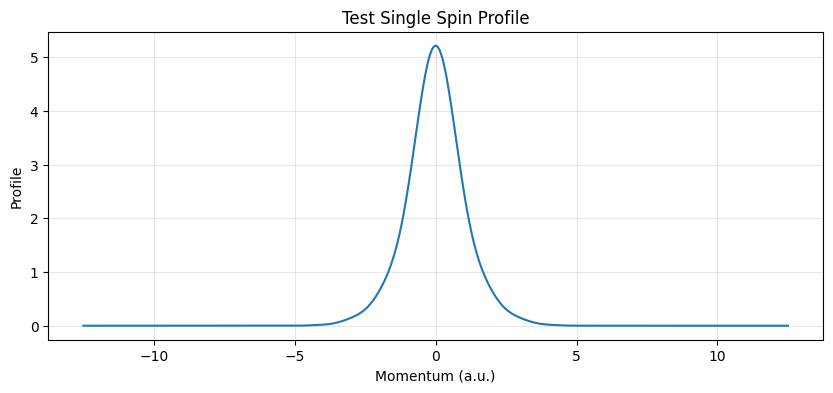

In [8]:
#Test...

def generate_single_spin_profile(x, n_gauss, gauss_width_range, gauss_amp_range, parab_curv_range, parab_offset_range, fermi_scale_range, fermi_coeff_range, rng):
    base_y , params = evaluate_base_model(x, n_gauss, gauss_width_range, gauss_amp_range, parab_curv_range, parab_offset_range,rng)
    y_up = add_fermi_features(base_y, x, fermi_window, fermi_scale_range, fermi_coeff_range, rng)

    return y_up



test_profile = generate_single_spin_profile(pz, n_gauss, gauss_width_range, gauss_amp_range, parab_curv_range, parab_offset_range, fermi_scale_range, fermi_coeff_range, rng)

plt.figure(figsize=(10, 4))
plt.plot(pz, test_profile)
plt.xlabel('Momentum (a.u.)')
plt.ylabel('Profile')
plt.title('Test Single Spin Profile')
plt.grid(True, alpha=0.3)
plt.show()


Successful (hopefully...)

Now build a full MCP:

In [9]:
def sign_consistent_integral(y, x, threshold=0.1):
    """
    Returns True if the signed integral is at least `threshold` × |total area|.
    This captures the physical requirement that the MCP has a net spin moment
    without demanding every single point be the same sign (unrealistic in tails).
    """
    signed_area = np.trapz(y, x)
    total_area  = np.trapz(np.abs(y), x)
    if total_area == 0:
        return False
    return abs(signed_area) / total_area >= threshold


def generate_mcp(x, n_gauss, gauss_width_range, gauss_amp_range,
                 parab_curv_range, parab_offset_range,
                 fermi_scale_range, fermi_coeff_range, rng,
                 max_attempts=50):
    """
    Generate one MCP sample.  Returns (clean, blur, noisy, blur_noisy) or None
    if no valid profile is found within max_attempts.
    """
    for _ in range(max_attempts):

        y_up = generate_single_spin_profile(
            x, n_gauss, gauss_width_range, gauss_amp_range,
            parab_curv_range, parab_offset_range,
            fermi_scale_range, fermi_coeff_range, rng)
        y_up = normalise(y_up, x)
        y_up_scaled = t_count * y_up

        y_down = generate_single_spin_profile(
            x, n_gauss, gauss_width_range, gauss_amp_range,
            parab_curv_range, parab_offset_range,
            fermi_scale_range, fermi_coeff_range, rng)
        y_down = normalise(y_down, x)
        y_down_scaled = t_count * y_down

        mcp_clean = y_up_scaled - spin_asymm * y_down_scaled

        # ── Physically motivated check (replaces strict sign_consistency) ──────
        if not sign_consistent_integral(mcp_clean, x, threshold=0.1):
            continue

        mcp_clean = normalise(mcp_clean, x)

        # ── Blurred and noisy variants ─────────────────────────────────────────
        y_up_blur   = blur(y_up_scaled, res_sigma)
        y_down_blur = blur(y_down_scaled, res_sigma)
        mcp_blur    = normalise(y_up_blur - spin_asymm * y_down_blur, x)

        y_up_noisy   = noise(y_up_scaled)
        y_down_noisy = noise(y_down_scaled)
        mcp_noisy    = normalise(y_up_noisy - spin_asymm * y_down_noisy, x)

        y_up_bn   = noise(y_up_blur)
        y_down_bn = noise(y_down_blur)
        mcp_bn    = normalise(y_up_bn - spin_asymm * y_down_bn, x)

        return mcp_clean, mcp_blur, mcp_noisy, mcp_bn

    # Exhausted attempts without finding a valid profile
    return None



C:\Users\Jpjha\AppData\Local\Temp\ipykernel_26056\874462221.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  signed_area = np.trapz(y, x)
C:\Users\Jpjha\AppData\Local\Temp\ipykernel_26056\874462221.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_area  = np.trapz(np.abs(y), x)
C:\Users\Jpjha\AppData\Local\Temp\ipykernel_26056\2397104712.py:47: RuntimeWarning: invalid value encountered in sqrt
  y_noisy = y + np.sqrt(y) * np.random.normal(0,noise_amp,size=y.shape)


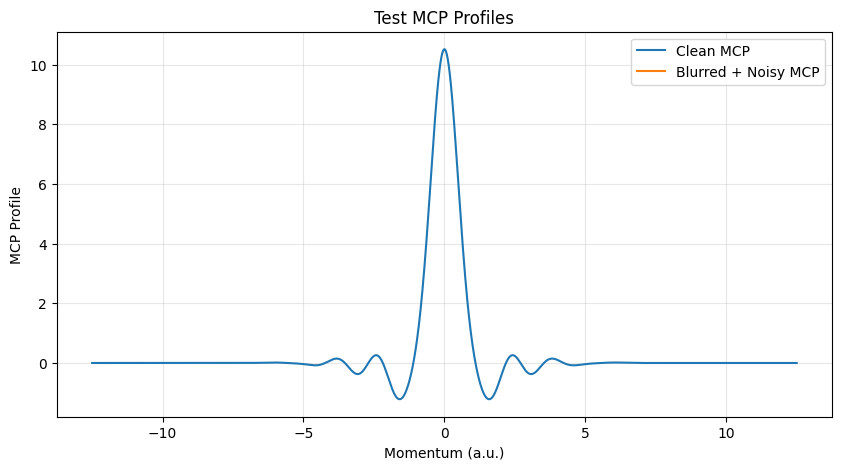

In [24]:
#Test...

from matplotlib.pyplot import figure, plot

#grid parameters
Npts = 2401
pz_min = -12.5
pz_max = 12.5

# Physical parameters
n_gauss = 4  # Real Ni shows 2-3 main peaks, not 5
fourier_order = 5  # Increase for realistic fine oscillations (was 10)
spin_asymm = 0.8  # Keep - realistic for magnetic materials

# Experimental parameters
t_count = 1e6  # Increase from 5e5 - reduces noise, clearer features
res_fwhm = 0.12  # Reduce from 0.45 - less blur, model learns realistic deconvolution
err_scaling = 1.2  # Slightly harder training data

# Random parameters
gauss_width_range = (0.4, 1.2)  # Narrower range - more realistic peak widths
gauss_amp_range = (0.15, 0.7)  # Avoid tiny/huge peaks
parab_curv_range = (-2.5, -1.5)  # Less extreme curvature
parab_offset_range = (0.1, 0.6)  # Tighter range for consistency

# Fermi parameters
fermi_window_width = 5  # Keep
fermi_window_amp = 1  # Keep
fermi_scale_range = (0.2, 0.4)  # Keep
fermi_coeff_range = 0.4  # Keep

n_train = 200000
n_test = 50000

pz = np.linspace(pz_min, pz_max, Npts)
grid_spacing = np.abs(pz[1] - pz[0])
res_sigma = res_fwhm / (2 * np.sqrt(2 * np.log(2))) / grid_spacing

rng = np.random.default_rng()

mcp_clean, mcp_blur, mcp_noisy, mcp_blur_noisy = generate_mcp(pz, n_gauss, gauss_width_range, gauss_amp_range, parab_curv_range, parab_offset_range, fermi_scale_range, fermi_coeff_range, rng)

figure(figsize=(10, 5))
plot(pz, mcp_clean, label='Clean MCP')
#plot(pz, mcp_blur, label='Blurred MCP')
#plot(pz, mcp_noisy, label='Noisy MCP')
plot(pz, mcp_blur_noisy, label='Blurred + Noisy MCP')
plt.xlabel('Momentum (a.u.)')
plt.ylabel('MCP Profile')
#plt.ylim(0,0.2)
plt.title('Test MCP Profiles')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [21]:
# fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

# configs = [
#     (x100, mcp100, mcp100_degrade, mcp100_blur_noise, '[100]'),
#     (x111, mcp111, mcp111_degrade, mcp111_blur_noise, '[111]'),
# ]

# for row, (x, mcp_clean, mcp_blur, mcp_bn, label) in enumerate(configs):

#     # ── Left: all three versions overlaid ─────────────────────────────────────
#     ax = axes[row, 0]
#     ax.plot(x, mcp_clean, lw=1.8, color='steelblue',  label='Theoretical (clean)')
#     ax.plot(x, mcp_blur,  lw=1.5, color='darkorange', label='Blurred (FWHM=0.35 a.u.)',
#             linestyle='--')
#     ax.plot(x, mcp_bn,    lw=1.0, color='tomato',     label='Blurred + Noisy',
#             alpha=0.85)
#     ax.axhline(0, color='k', lw=0.6, ls=':')
#     ax.set_title(f'Ni {label} — MCP  (spin asymmetry = 0.8)', fontsize=11)
#     ax.set_xlabel('pz (a.u.)'); ax.set_ylabel('J(pz) (arb. units)')
#     ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

#     # ── Right: residual (blur+noisy − clean) ──────────────────────────────────
#     ax = axes[row, 1]
#     # Interpolate blurred+noisy onto the clean grid for fair subtraction
#     from scipy.interpolate import interp1d
#     residual = mcp_bn - mcp_clean
#     ax.plot(x, residual, lw=1.0, color='tomato', alpha=0.9, label='(Blur+Noisy) − Clean')
#     ax.axhline(0, color='k', lw=0.8, ls='--')
#     rms = np.sqrt(np.mean(residual**2))
#     ax.set_title(f'Ni {label} — Degradation residual  (RMS = {rms:.4f})', fontsize=11)
#     ax.set_xlabel('pz (a.u.)'); ax.set_ylabel('Δ J(pz)')
#     ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# plt.suptitle('Ni Magnetic Compton Profiles  —  theoretical vs experimental simulation',
#              fontsize=13, y=1.01)
# plt.tight_layout()
# plt.show()

In [19]:
# def fit_theoretical_profile(pz, cp, n_gauss=3, fourier_order=10,
#                             initial_guesses=None, verbose=True):
#     """
#     Fit a Compton profile with Gaussians + a Hann-windowed Fourier correction.

#     The Hann window applied to the lstsq Fourier coefficients suppresses the
#     Gibbs ringing that appears when a sharp residual peak is represented by a
#     truncated cosine/sine basis.
#     """
#     # ── Gaussian initial guesses ───────────────────────────────────────────────
#     if initial_guesses is None:
#         if n_gauss == 3:
#             initial_guesses = [(0.5, 0.8), (1.5, 0.2), (3.0, 0.1)]
#         else:
#             initial_guesses = [(0.5 * (i + 1), 0.8 / (i + 1)) for i in range(n_gauss)]

#     p0           = [p for pair in initial_guesses for p in pair]
#     lower_bounds = [0.05, 0.0] * n_gauss   # allow narrower peaks
#     upper_bounds = [10.0, 5.0] * n_gauss   # allow larger amps

#     def gauss_model(x, *args):
#         y = np.zeros_like(x)
#         for i in range(n_gauss):
#             # FIXED: no spurious factor of 2 in denominator
#             w, a = args[i * 2], args[i * 2 + 1]
#             y += np.abs(a) * np.exp(-0.5 * (x / np.abs(w)) ** 2)
#         return y

#     popt, pcov = curve_fit(gauss_model, pz, cp, p0,
#                            bounds=(lower_bounds, upper_bounds),
#                            method='trf', max_nfev=1_000_000)

#     gauss_fit   = gauss_model(pz, *popt)
#     gauss_params = [(popt[i*2], popt[i*2+1]) for i in range(n_gauss)]

#     if verbose:
#         for i, (w, a) in enumerate(gauss_params):
#             print(f'  Gaussian {i+1}: σ = {w:.4f},  amp = {a:.4f}')

#     residuals = cp - gauss_fit

#     # ── Windowed Fourier fit to residuals ─────────────────────────────────────
#     # Fundamental frequency: one full cycle across the pz domain
#     f0 = 2 * np.pi / (pz[-1] - pz[0])

#     cols = [np.ones_like(pz)]
#     for i in range(1, fourier_order + 1):
#         cols.append(np.cos(i * f0 * pz))
#         cols.append(np.sin(i * f0 * pz))
#     A      = np.column_stack(cols)
#     coeffs, _, _, _ = np.linalg.lstsq(A, residuals, rcond=None)

#     # Hann window over the harmonic indices 0..fourier_order
#     # w[k] = 0.5*(1 - cos(π*k/N))  →  tapers high-frequency coefficients to zero
#     # This eliminates Gibbs ringing without losing the low-frequency correction.
#     N = fourier_order
#     hann = np.array([0.5 * (1 - np.cos(np.pi * k / N))
#                      for k in range(N + 1)])   # length N+1, one per harmonic

#     # Apply window: dc term kept as-is; cos/sin pairs share the same harmonic index
#     windowed_coeffs        = coeffs.copy()
#     windowed_coeffs[0]    *= hann[0]           # DC offset
#     for k in range(1, fourier_order + 1):
#         windowed_coeffs[2*k - 1] *= hann[k]   # cos coefficient
#         windowed_coeffs[2*k]     *= hann[k]   # sin coefficient

#     fourier_fit = A @ windowed_coeffs          # windowed reconstruction
#     complete_fit = gauss_fit + fourier_fit

#     if verbose:
#         rms_gauss    = np.sqrt(np.mean(residuals**2))
#         rms_complete = np.sqrt(np.mean((cp - complete_fit)**2))
#         print(f'\n  RMS after Gaussian only : {rms_gauss:.5f}')
#         print(f'  RMS after Fourier corr. : {rms_complete:.5f}')
#         print(f'  Fourier order used      : {fourier_order}  (Hann windowed)')

#     return {
#         'gauss_params'  : gauss_params,
#         'gauss_fit'     : gauss_fit,
#         'fourier_fit'   : fourier_fit,
#         'complete_fit'  : complete_fit,
#         'residuals'     : residuals,
#         'popt'          : popt,
#         'pcov'          : pcov,
#     }


# # ── Run fits ──────────────────────────────────────────────────────────────────
# print('Fitting Ni [100]...')
# fit100 = fit_theoretical_profile(x100, mcp100, n_gauss=3, fourier_order=10, verbose=True)

# print('\nFitting Ni [111]...')
# fit111 = fit_theoretical_profile(x111, mcp111, n_gauss=3, fourier_order=10, verbose=True)

# print(fit111)

# # ── Diagnostic plot (same layout as before) ───────────────────────────────────
# fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# for row, (label, x, mcp, fit) in enumerate([
#         ('[100]', x100, mcp100, fit100),
#         ('[111]', x111, mcp111, fit111)]):

#     ax = axes[row, 0]
#     ax.plot(x, mcp,                 lw=1.5,                label='Theoretical MCP')
#     ax.plot(x, fit['gauss_fit'],    lw=1.5, ls='--',       label='Gaussian fit')
#     ax.plot(x, fit['complete_fit'], lw=1.5, ls='-.',       label='Gaussian + windowed Fourier')
#     ax.set_title(f'Ni {label} — Profile fits');  ax.set_xlabel('pz (a.u.)'); ax.set_ylabel('MCP')
#     ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

#     ax = axes[row, 1]
#     ax.plot(x, fit['residuals'],   lw=1.2,               label='Gauss residuals')
#     ax.plot(x, fit['fourier_fit'], lw=1.5, ls='--',      label='Fourier corr. (Hann-windowed)')
#     ax.set_title(f'Ni {label} — Fourier component'); ax.set_xlabel('pz (a.u.)'); ax.set_ylabel('Residual')
#     ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

#     ax = axes[row, 2]
#     final_res = mcp - fit['complete_fit']
#     ax.plot(x, final_res, lw=1.2, color='tomato', label='Final residual')
#     ax.axhline(0, color='k', lw=0.8, ls='--')
#     rms = np.sqrt(np.mean(final_res**2))
#     ax.set_title(f'Ni {label} — Final residual (RMS={rms:.4f})')
#     ax.set_xlabel('pz (a.u.)'); ax.set_ylabel('MCP − complete fit')
#     ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# plt.suptitle('fit_theoretical_profile — Ni [100] and [111]  (Hann-windowed Fourier)', fontsize=13)
# plt.tight_layout()
# plt.show()


In [20]:
# print('Fitting Ni [100] spin-up component...')
# fit100_1 = fit_theoretical_profile(x100, y100_1, n_gauss=3, fourier_order=10, verbose=True)

# print('\nFitting Ni [100] spin-down component...')
# fit100_2 = fit_theoretical_profile(x100, y100_2, n_gauss=3, fourier_order=10, verbose=True)

# # Form MCP from the two fitted profiles
# mcp100_from_fits = fit100_1['complete_fit'] - 0.8 * fit100_2['complete_fit']

# # ── Plot ──────────────────────────────────────────────────────────────────────
# fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# # Panel 1: individual fitted spin components
# ax = axes[0]
# ax.plot(x100, y100_1,                    lw=1.2, color='steelblue',  alpha=0.5, label='J↑ data')
# ax.plot(x100, fit100_1['complete_fit'],  lw=1.8, color='steelblue',  label='J↑ fit')
# ax.plot(x100, y100_2,                    lw=1.2, color='tomato',     alpha=0.5, label='J↓ data')
# ax.plot(x100, fit100_2['complete_fit'],  lw=1.8, color='tomato',     label='J↓ fit')
# ax.set_title('Ni [100] — individual spin component fits')
# ax.set_xlabel('pz (a.u.)'); ax.set_ylabel('J(pz) (arb. units)')
# ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# # Panel 2: MCP from raw data vs MCP from fits
# ax = axes[1]
# ax.plot(x100, mcp100,            lw=1.5, color='steelblue', label='MCP from data  (J↑ − 0.8·J↓)')
# ax.plot(x100, mcp100_from_fits,  lw=1.8, color='darkorange', ls='--',
#         label='MCP from fits  (fit↑ − 0.8·fit↓)')
# ax.axhline(0, color='k', lw=0.6, ls=':')
# ax.set_title('Ni [100] — MCP: data vs fitted')
# ax.set_xlabel('pz (a.u.)'); ax.set_ylabel('MCP (arb. units)')
# ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# # Panel 3: residual between the two MCPs
# ax = axes[2]
# mcp_residual = mcp100 - mcp100_from_fits
# rms = np.sqrt(np.mean(mcp_residual**2))
# ax.plot(x100, mcp_residual, lw=1.2, color='tomato', label=f'Residual  (RMS = {rms:.5f})')
# ax.axhline(0, color='k', lw=0.8, ls='--')
# ax.set_title('Ni [100] — MCP residual (data − fit)')
# ax.set_xlabel('pz (a.u.)'); ax.set_ylabel('ΔMCP')
# ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# plt.suptitle('Ni [100]  —  MCP from fitted spin components  (spin asymmetry = 0.8)', fontsize=13)
# plt.tight_layout()
# plt.show()

# print(f'\nMCP from fits — min: {mcp100_from_fits.min():.5f},  max: {mcp100_from_fits.max():.5f}')
# print(f'MCP from data — min: {mcp100.min():.5f},  max: {mcp100.max():.5f}')
# print(f'RMS residual  : {rms:.5f}')

# Build training datasets:


* tails rising? $\checkmark$
* centre not physical looking $\checkmark$
* blur is wrong still - I think?




Blur might be wrong but its good enough so time to create enough of these to train a CNN and then train and test the CNN. can test on some real profiles. 

In [11]:
import pickle
import numpy as np
from tqdm import tqdm
from datetime import datetime

def build_mcp_dataset(n_samples, pz, n_gauss, gauss_width_range, gauss_amp_range,
                     parab_curv_range, parab_offset_range, fermi_scale_range, 
                     fermi_coeff_range, rng, desc="Generating"):
    """
    Build a dataset of MCP profiles.
    
    Returns:
        Dictionary with arrays for each version of the MCP
    """
    clean_list = []
    blur_list = []
    noisy_list = []
    blur_noisy_list = []
    
    attempts = 0
    max_attempts = n_samples * 20  # Allow some failures
    
    with tqdm(total=n_samples, desc=desc) as pbar:
        while len(clean_list) < n_samples and attempts < max_attempts:
            attempts += 1
            
            result = generate_mcp(pz, n_gauss, gauss_width_range, gauss_amp_range,
                                parab_curv_range, parab_offset_range, 
                                fermi_scale_range, fermi_coeff_range, rng)
            
            if result is not None:
                mcp_clean, mcp_blur, mcp_noisy, mcp_blur_noisy = result
                
                clean_list.append(mcp_clean)
                blur_list.append(mcp_blur)
                noisy_list.append(mcp_noisy)
                blur_noisy_list.append(mcp_blur_noisy)
                
                pbar.update(1)
    
    if len(clean_list) < n_samples:
        print(f"\nWarning: Only generated {len(clean_list)}/{n_samples} valid profiles")
    
    rejection_rate = (attempts - len(clean_list)) / attempts * 100
    print(f"Rejection rate: {rejection_rate:.2f}% ({attempts - len(clean_list)}/{attempts})")
    
    return {
        'clean': np.array(clean_list),
        'blur': np.array(blur_list),
        'noisy': np.array(noisy_list),
        'blur_noisy': np.array(blur_noisy_list),
        'pz': pz,
        'metadata': {
            'n_samples': len(clean_list),
            'n_gaussians': n_gauss,
            'total_counts': t_count,
            'resolution_fwhm': res_fwhm,
            'spin_asymmetry': spin_asymm,
            'generation_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
    }


# Generate Training Dataset (4000 samples)
print("="*70)
print("GENERATING NICKEL MCP TRAINING DATASET")
print("="*70)
print(f"Target: 4000 training profiles\n")

train_data = build_mcp_dataset(
    n_samples=4000,
    pz=pz,
    n_gauss=n_gauss,
    gauss_width_range=gauss_width_range,
    gauss_amp_range=gauss_amp_range,
    parab_curv_range=parab_curv_range,
    parab_offset_range=parab_offset_range,
    fermi_scale_range=fermi_scale_range,
    fermi_coeff_range=fermi_coeff_range,
    rng=rng,
    desc="Training set"
)

print(f"\n✓ Training dataset complete")
print(f"  Shape: {train_data['clean'].shape}")
print(f"  Memory: ~{train_data['clean'].nbytes * 4 / 1e6:.1f} MB")


# Generate Test Dataset (1000 samples)
print("\n" + "="*70)
print("GENERATING NICKEL MCP TEST DATASET")
print("="*70)
print(f"Target: 1000 test profiles\n")

test_data = build_mcp_dataset(
    n_samples=1000,
    pz=pz,
    n_gauss=n_gauss,
    gauss_width_range=gauss_width_range,
    gauss_amp_range=gauss_amp_range,
    parab_curv_range=parab_curv_range,
    parab_offset_range=parab_offset_range,
    fermi_scale_range=fermi_scale_range,
    fermi_coeff_range=fermi_coeff_range,
    rng=rng,
    desc="Test set"
)

print(f"\n✓ Test dataset complete")
print(f"  Shape: {test_data['clean'].shape}")
print(f"  Memory: ~{test_data['clean'].nbytes * 4 / 1e6:.1f} MB")


# Save datasets as pickle files
print("\n" + "="*70)
print("SAVING DATASETS")
print("="*70)

# Save training data
train_filename = 'nickel_mcp_train_4000.pkl'
with open(train_filename, 'wb') as f:
    pickle.dump(train_data, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"✓ Saved: {train_filename}")
#print(f"  Size: {os.path.getsize(train_filename) / 1e6:.2f} MB")

# Save test data
test_filename = 'nickel_mcp_test_1000.pkl'
with open(test_filename, 'wb') as f:
    pickle.dump(test_data, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"✓ Saved: {test_filename}")
#print(f"  Size: {os.path.getsize(test_filename) / 1e6:.2f} MB")


GENERATING NICKEL MCP TRAINING DATASET
Target: 4000 training profiles



Training set:  61%|██████    | 2440/4000 [00:18<00:11, 132.41it/s]


KeyboardInterrupt: 

In [ ]:
filepath = "C:\\Users\\Jpjha\\OneDrive\\Desktop\\Decon by ML\\Code\\nickel_mcp_train_4000.pkl"
training_data = pd.read_pickle(filepath)

training_data['clean']

array([[0.42519607, 0.42579257, 0.42638405, ..., 0.42638405, 0.42579257,
        0.42519607],
       [0.43059079, 0.43129309, 0.43195846, ..., 0.43195846, 0.43129309,
        0.43059079],
       [0.56770314, 0.56874629, 0.56980349, ..., 0.56980349, 0.56874629,
        0.56770314],
       ...,
       [0.31113028, 0.31150517, 0.31186788, ..., 0.31186788, 0.31150517,
        0.31113028],
       [0.26224694, 0.26259169, 0.26294832, ..., 0.26294832, 0.26259169,
        0.26224694],
       [0.53705925, 0.53795408, 0.53884156, ..., 0.53884156, 0.53795408,
        0.53705925]], shape=(4000, 2401))

In [ ]:
import pickle
import numpy as np

print("="*70)
print("CREATING 4-SAMPLE VISUALIZATION DATASET")
print("="*70)

# Generate 4 samples
viz_samples = {
    'clean': [],
    'blur': [],
    'noisy': [],
    'blur_noisy': []
}

print("\nGenerating 4 validation samples...")

count = 0
attempts = 0
max_attempts = 50

while count < 4 and attempts < max_attempts:
    attempts += 1
    
    result = generate_mcp(pz, n_gauss, gauss_width_range, gauss_amp_range,
                         parab_curv_range, parab_offset_range, 
                         fermi_scale_range, fermi_coeff_range, rng)
    
    if result is not None:
        mcp_clean, mcp_blur, mcp_noisy, mcp_blur_noisy = result
        
        viz_samples['clean'].append(mcp_clean)
        viz_samples['blur'].append(mcp_blur)
        viz_samples['noisy'].append(mcp_noisy)
        viz_samples['blur_noisy'].append(mcp_blur_noisy)
        
        count += 1
        print(f"  ✓ Sample {count} generated")

# Convert to arrays
viz_data = {
    'clean': np.array(viz_samples['clean']),
    'blur': np.array(viz_samples['blur']),
    'noisy': np.array(viz_samples['noisy']),
    'blur_noisy': np.array(viz_samples['blur_noisy']),
    'pz': pz
}

# Save
filename = 'nickel_mcp_viz_4samples.pkl'
with open(filename, 'wb') as f:
    pickle.dump(viz_data, f)

print(f"\n✓ Saved: {filename}")
print(f"  Shapes: {viz_data['clean'].shape}")
print(f"\nTo load:")
print(f"  with open('{filename}', 'rb') as f:")
print(f"      viz_data = pickle.load(f)")
print(f"  X_viz = viz_data['blur_noisy']  # Inputs")
print(f"  y_viz = viz_data['clean']       # Targets")

CREATING 4-SAMPLE VISUALIZATION DATASET

Generating 4 validation samples...
  ✓ Sample 1 generated
  ✓ Sample 2 generated
  ✓ Sample 3 generated
  ✓ Sample 4 generated

✓ Saved: nickel_mcp_viz_4samples.pkl
  Shapes: (4, 2401)

To load:
  with open('nickel_mcp_viz_4samples.pkl', 'rb') as f:
      viz_data = pickle.load(f)
  X_viz = viz_data['blur_noisy']  # Inputs
  y_viz = viz_data['clean']       # Targets


# Theoretical MCPs:


* loading some theoretical MCPs to degrade and test on the CNN
* will also aide with the optimisation of training data

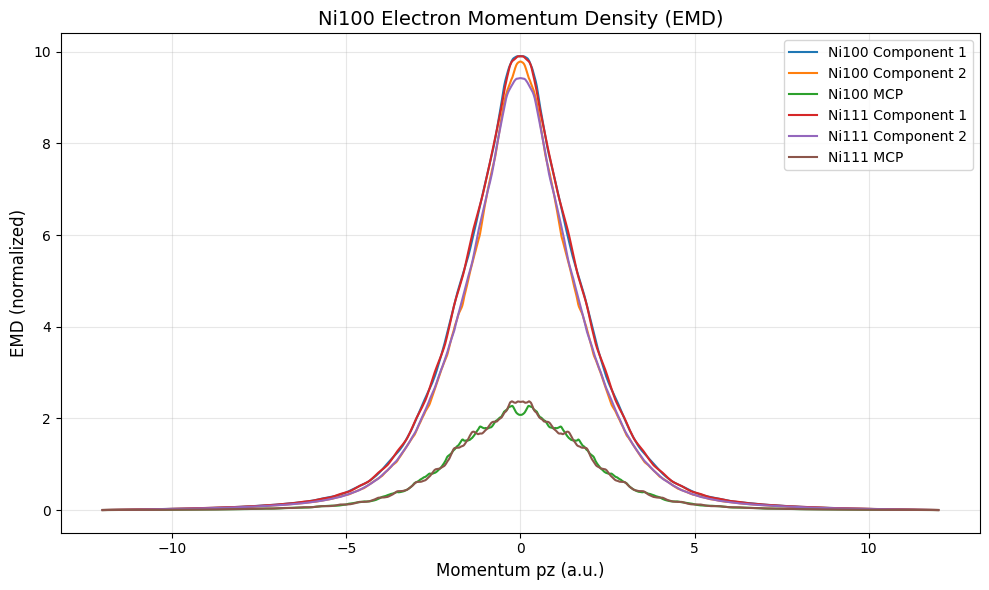

(2401,) (2401,) (2401,)


In [12]:
ni100 = np.loadtxt('Ni_Magnetic_Compton/I_EMD1D.OUT.100', comments = '%')
ni111 = np.loadtxt('Ni_Magnetic_Compton/I_EMD1D.OUT.111', comments = '%')

sf = 1e3

x100 = ni100[:,0]
y100_1 = ni100[:,1] * sf
y100_2 = ni100[:,2] * sf
mcp100 = y100_1 - 0.8 * y100_2

x111= ni111[:,0]
y111_1 = ni111[:,1] * sf
y111_2 = ni111[:,2] * sf
mcp111 = y111_1 - 0.8 * y111_2

plt.figure(figsize=(10, 6))
plt.plot(x100, y100_1, label='Ni100 Component 1')
plt.plot(x100, y100_2, label='Ni100 Component 2')
plt.plot(x100, mcp100, label='Ni100 MCP')
plt.plot(x111, y111_1, label='Ni111 Component 1')
plt.plot(x111, y111_2, label='Ni111 Component 2')
plt.plot(x111, mcp111, label='Ni111 MCP')
plt.xlabel('Momentum pz (a.u.)', fontsize=12)
plt.ylabel('EMD (normalized)', fontsize=12)
plt.title('Ni100 Electron Momentum Density (EMD)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(x100.shape, y100_1.shape, y100_2.shape)

Redefining parameters and functions where values need changing to account for new scale

In [14]:
#grid parameters
Npts = 2401
pz_min = -12.5
pz_max = 12.5

# physical parameters
n_gauss = 5
fourier_order = 5
spin_asymm = 0.8

# experimental parameters
t_count = 5e5
res_fwhm = 0.35
err_scaling = 1

# random parameters
gauss_width_range = (0.3, 2.0)
gauss_amp_range = (0.05, 1.0)
parab_curv_range = (-2.5, -1.5)
parab_offset_range = (1.5, 2.5)

fermi_window_width = 2
fermi_window_amp = 0.5
fermi_scale_range = (0.1, 0.2)
fermi_coeff_range = 0.3

noise_amp = 0.01

n_train = 200000
n_test = 50000

pz = np.linspace(pz_min, pz_max, Npts)
grid_spacing = np.abs(pz[1] - pz[0])
res_sigma = res_fwhm / (2 * np.sqrt(2 * np.log(2))) / grid_spacing


rng = np.random.default_rng()


def blur(y, sigma):
    kernel = gaussian_kernel_1D(size=101, sigma=sigma)
    y = signal.convolve(y, kernel, mode='same')

    return y

def noise(y):
    y_noisy = y + np.sqrt(y) * np.random.normal(0,noise_amp,size=y.shape)
    return y_noisy


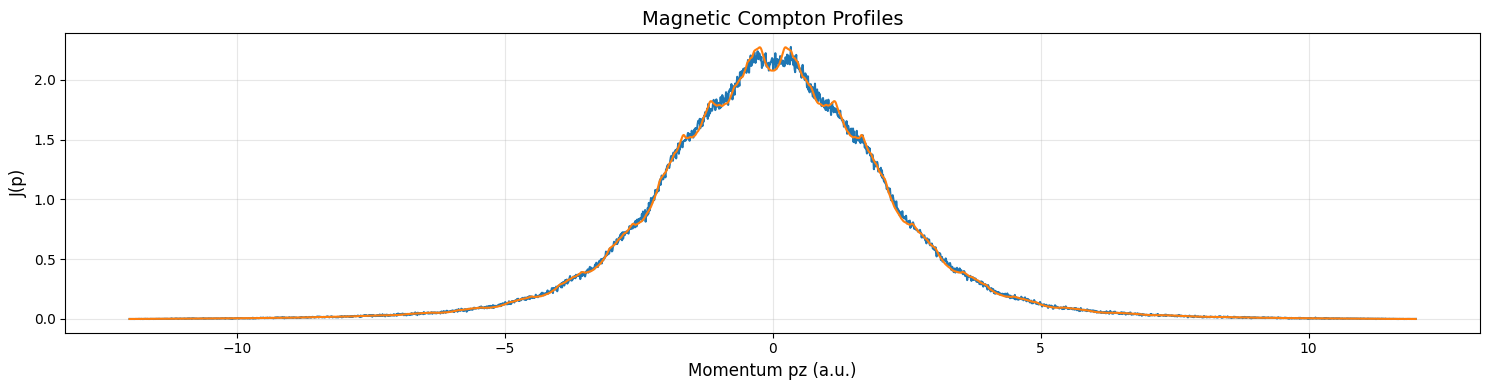

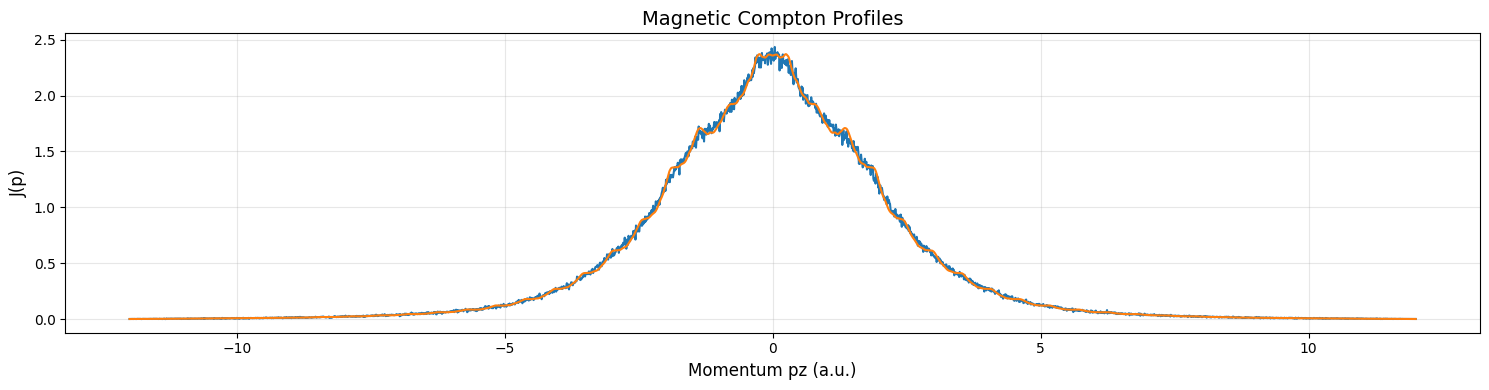

In [15]:
y100_1_blur = blur(y100_1, res_sigma)
y100_1_blur_noise= noise(y100_1_blur)
y100_2_blur = blur(y100_2, res_sigma)
y100_2_blur_noise = noise(y100_2_blur)

mcp100_blur_noise = y100_1_blur_noise - 0.8 * y100_2_blur_noise

y111_1_blur = blur(y111_1, res_sigma)
y111_1_blur_noise= noise(y111_1_blur)
y111_2_blur = blur(y111_2, res_sigma)
y111_2_blur_noise = noise(y111_2_blur)

mcp111_blur_noise = y111_1_blur_noise - 0.8 * y111_2_blur_noise

mcp100_degrade = blur(mcp100, res_sigma)
mcp111_degrade = blur(mcp111, res_sigma)

plt.figure(figsize=(15, 4))
plt.plot(x100, mcp100_blur_noise)
plt.plot(x100, mcp100)
plt.xlabel('Momentum pz (a.u.)', fontsize=12)
plt.ylabel('J(p)', fontsize=12)
plt.title('Magnetic Compton Profiles', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(x100, mcp111_blur_noise)
plt.plot(x111, mcp111)
plt.xlabel('Momentum pz (a.u.)', fontsize=12)
plt.ylabel('J(p)', fontsize=12)
plt.title('Magnetic Compton Profiles', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Save the test profiles for use in other files
import pickle

# Save both profiles together with metadata
profiles_data_100 = {
    'mcp_clean': mcp100,
    'mcp_blur_noisy': mcp100_blur_noise,
    'pz': x100
}

profiles_data_111 = {
    'mcp_clean': mcp111,
    'mcp_blur_noisy': mcp111_blur_noise,
    'pz': x111
}

# Save as pickle file
filename_100 = 'Nickel_100_profiles.pkl'
with open(filename_100, 'wb') as f:
    pickle.dump(profiles_data_100, f)

filename_111 = 'Nickel_111_profiles.pkl'
with open(filename_111, 'wb') as f:
    pickle.dump(profiles_data_111, f)

print(f"✓ Saved profiles to: {filename_100}, {filename_111}")
print(f"  Clean shape: {mcp100.shape}")
print(f"  Blur+Noisy shape: {mcp100_blur_noise.shape}")
print(f"  Clean shape: {mcp111.shape}")
print(f"  Blur+Noisy shape: {mcp111_blur_noise.shape}")


✓ Saved profiles to: Nickel_100_profiles.pkl, Nickel_111_profiles.pkl
  Clean shape: (2401,)
  Blur+Noisy shape: (2401,)
  Clean shape: (2401,)
  Blur+Noisy shape: (2401,)


## Filtering the synthetic profiles

Building a system to filter out potentially viable syntetic MCPs from unphysical ones

In [ ]:
'''

The Following code was produced using Claude AI 

prompt: 
take redced chi squared of syntetic mcp against each direction
if smallest value is greater than a target value then reject the profile
accpeted profiles are affed to the dataframe to produce pickle data
repeat until 4000 profiles are accepted for training and 1000 for testing

It has since been edited

'''

from scipy.interpolate import interp1d
import pickle
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

noise_amp = 30

def noise(y):
    y_noisy = y + np.sqrt(np.abs(y)) * np.random.normal(0,3,size=y.shape)
    return y_noisy



# ── Configuration ─────────────────────────────────────────────────────────────
N_TRAIN        = 3000
N_TEST         = 1000
CHI2_THRESHOLD = 3.5    # reject if best reduced chi-sq across both orientations exceeds this
                         # tune this — tighter (~2) = more physical, looser (~10) = more variety

# Use the DFT theoretical profiles already loaded in this notebook as reference.
# Since there are no experimental error bars, we estimate the noise floor as a
# fixed fraction of the peak amplitude of each reference profile.
NOISE_FRACTION = 0.05   # 5% of peak amplitude used as proxy error bar

reference_profiles = {
    '100': {'pz': x100, 'mcp': mcp100},
    '111': {'pz': x111, 'mcp': mcp111},
}

# ── Helper: reduced chi-squared ───────────────────────────────────────────────
def reduced_chi_squared(pz_synth, mcp_synth, pz_ref, mcp_ref):
    """
    Interpolates the synthetic profile onto the reference pz grid and computes
    a reduced chi-squared.  Since we have no experimental error bars, a uniform
    error equal to NOISE_FRACTION * peak(mcp_ref) is assumed across all points.

    Parameters
    ----------
    pz_synth  : 1-D array  momentum axis of synthetic profile (2401 pts, ±12.5)
    mcp_synth : 1-D array  synthetic MCP values
    pz_ref    : 1-D array  reference (DFT) momentum axis
    mcp_ref   : 1-D array  reference MCP values

    Returns
    -------
    float  reduced chi-squared
    """
    # Restrict comparison to the overlapping momentum range
    pz_lo = max(pz_synth.min(), pz_ref.min())
    pz_hi = min(pz_synth.max(), pz_ref.max())

    mask       = (pz_ref >= pz_lo) & (pz_ref <= pz_hi)
    pz_cut     = pz_ref[mask]
    mcp_ref_cut = mcp_ref[mask]

    # Interpolate synthetic onto reference grid
    interp_fn     = interp1d(pz_synth, mcp_synth, kind='cubic')
    mcp_synth_cut = interp_fn(pz_cut)

    # Normalise synthetic so its integral matches the reference
    norm_ref   = np.trapz(mcp_ref_cut,   pz_cut)
    norm_synth = np.trapz(mcp_synth_cut, pz_cut)
    if norm_synth == 0:
        return np.inf
    mcp_synth_cut *= norm_ref / norm_synth

    # Proxy error: fixed fraction of reference peak amplitude
    error = NOISE_FRACTION * np.max(np.abs(mcp_ref_cut))
    if error == 0:
        return np.inf

    n_points = len(pz_cut)
    chi2     = np.sum(((mcp_ref_cut - mcp_synth_cut) / error) ** 2)
    return chi2 / n_points


# ── Generation loop ───────────────────────────────────────────────────────────
records_train = []
records_test  = []
n_accepted    = 0
n_rejected    = 0
target_total  = N_TRAIN + N_TEST

pbar = tqdm(total=target_total, desc='Generating filtered profiles')

while n_accepted < target_total:

    # Generate a candidate synthetic MCP
    result = generate_mcp(
        pz, n_gauss, gauss_width_range, gauss_amp_range,
        parab_curv_range, parab_offset_range,
        fermi_scale_range, fermi_coeff_range, rng
    )

    # generate_mcp returns None (via recursion guard) if sign_consistency fails;
    # guard against that here just in case
    if result is None:
        n_rejected += 1
        continue

    mcp_clean, mcp_blur, mcp_noisy, mcp_blur_noisy = result

    # Compute reduced chi-squared against each reference orientation
    chi2_per_orientation = {
        ori: reduced_chi_squared(
            pz_synth  = pz,
            mcp_synth = mcp_clean,
            pz_ref    = reference_profiles[ori]['pz'],
            mcp_ref   = reference_profiles[ori]['mcp']
        )
        for ori in reference_profiles
    }

    best_chi2        = min(chi2_per_orientation.values())
    best_orientation = min(chi2_per_orientation, key=chi2_per_orientation.get)

    # Reject if no orientation gives a close enough match
    if best_chi2 > CHI2_THRESHOLD:
        n_rejected += 1
        continue

    # Build record
    record = {
        'mcp_clean'       : mcp_clean,
        'mcp_blur'        : mcp_blur,
        'mcp_noisy'       : mcp_noisy,
        'mcp_blur_noisy'  : mcp_blur_noisy,
        'pz'              : pz,
        'best_chi2'       : best_chi2,
        'best_orientation': best_orientation,
        **{f'chi2_{ori}': chi2_per_orientation[ori] for ori in reference_profiles}
    }

    # Fill train first, then test
    if len(records_train) < N_TRAIN:
        records_train.append(record)
    else:
        records_test.append(record)

    n_accepted += 1
    pbar.update(1)

pbar.close()

total_attempts = n_accepted + n_rejected
print(f'\nFinished: {n_accepted} accepted, {n_rejected} rejected '
      f'({100 * n_rejected / total_attempts:.1f}% rejection rate)')

# ── Assemble and save ─────────────────────────────────────────────────────────
df_train = pd.DataFrame(records_train)
df_test  = pd.DataFrame(records_test)

# Also expose as numpy arrays in the same format as build_mcp_dataset above,
# so the rest of the notebook (CNN training cells) can use either output format.
train_data = {
    'clean'      : np.stack(df_train['mcp_clean'].values),
    'blur'       : np.stack(df_train['mcp_blur'].values),
    'noisy'      : np.stack(df_train['mcp_noisy'].values),
    'blur_noisy' : np.stack(df_train['mcp_blur_noisy'].values),
    'pz'         : pz,
    'chi2'       : df_train['best_chi2'].values,
    'metadata'   : {
        'n_samples'       : len(df_train),
        'chi2_threshold'  : CHI2_THRESHOLD,
        'noise_fraction'  : NOISE_FRACTION,
        'n_gaussians'     : n_gauss,
        'total_counts'    : t_count,
        'resolution_fwhm' : res_fwhm,
        'spin_asymmetry'  : spin_asymm,
        'generation_date' : datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }
}

test_data = {
    'clean'      : np.stack(df_test['mcp_clean'].values),
    'blur'       : np.stack(df_test['mcp_blur'].values),
    'noisy'      : np.stack(df_test['mcp_noisy'].values),
    'blur_noisy' : np.stack(df_test['mcp_blur_noisy'].values),
    'pz'         : pz,
    'chi2'       : df_test['best_chi2'].values,
    'metadata'   : {**train_data['metadata'], 'n_samples': len(df_test)}
}

train_filename = 'nickel_mcp_train_filtered_4000.pkl'
test_filename  = 'nickel_mcp_test_filtered_1000.pkl'

with open(train_filename, 'wb') as f:
    pickle.dump(train_data, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(test_filename, 'wb') as f:
    pickle.dump(test_data, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f'\n✓ Saved: {train_filename}  —  shape: {train_data["clean"].shape}')
print(f'✓ Saved: {test_filename}   —  shape: {test_data["clean"].shape}')
print(f'\nchi² summary (training set):')
print(f'  mean : {df_train["best_chi2"].mean():.3f}')
print(f'  std  : {df_train["best_chi2"].std():.3f}')
print(f'  max  : {df_train["best_chi2"].max():.3f}')
print(f'  best_orientation breakdown:\n{df_train["best_orientation"].value_counts().to_string()}')

Generating filtered profiles:   0%|          | 7/4000 [00:07<1:06:54,  1.01s/it]
C:\Users\Jpjha\AppData\Local\Temp\ipykernel_5808\4021297363.py:77: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_ref   = np.trapz(mcp_ref_cut,   pz_cut)
C:\Users\Jpjha\AppData\Local\Temp\ipykernel_5808\4021297363.py:78: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_synth = np.trapz(mcp_synth_cut, pz_cut)
Generating filtered profiles: 100%|██████████| 4000/4000 [45:10<00:00,  1.48it/s]  



Finished: 4000 accepted, 25101 rejected (86.3% rejection rate)

✓ Saved: nickel_mcp_train_filtered_4000.pkl  —  shape: (3000, 2401)
✓ Saved: nickel_mcp_test_filtered_1000.pkl   —  shape: (1000, 2401)

chi² summary (training set):
  mean : 1.977
  std  : 0.918
  max  : 3.500
  best_orientation breakdown:
best_orientation
111    2085
100     915


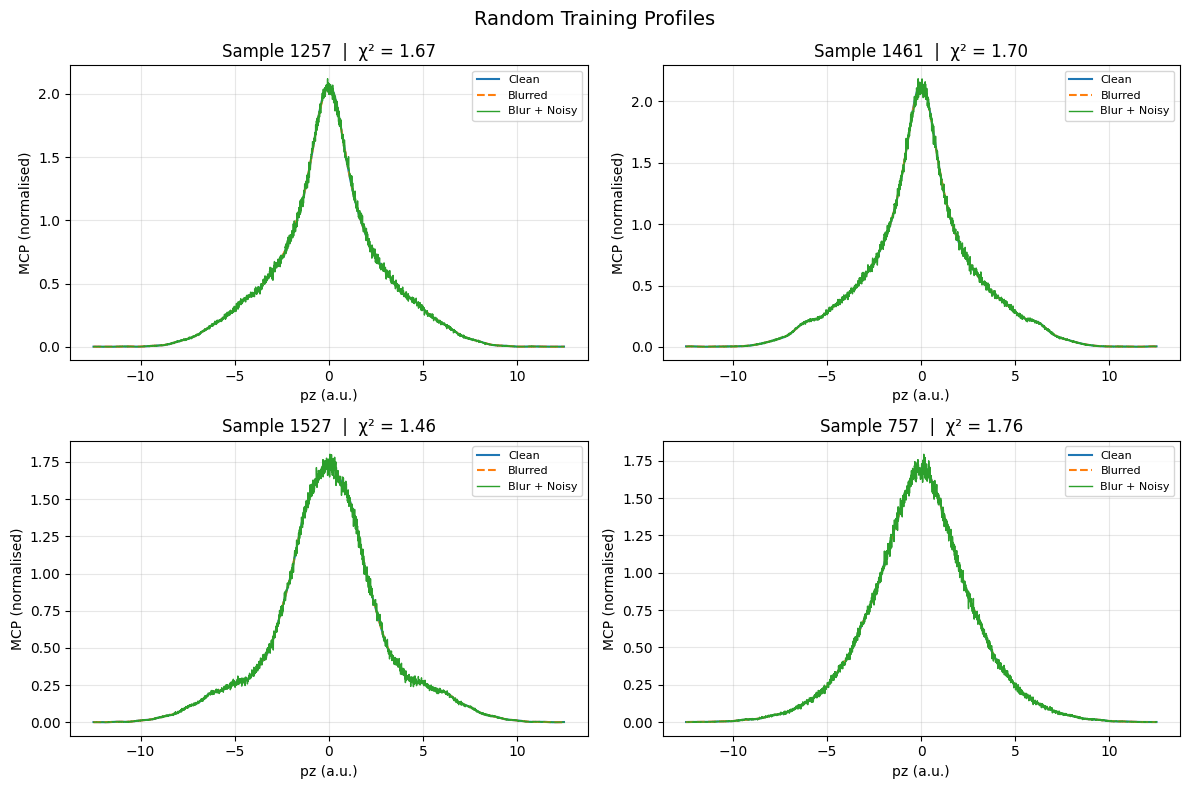

In [ ]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

with open('nickel_mcp_train_filtered_4000.pkl', 'rb') as f:
    train_data = pickle.load(f)

pz = train_data['pz']
indices = np.random.choice(len(train_data['clean']), 4, replace=False)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, idx in enumerate(indices):
    axs[i].plot(pz, train_data['clean'][idx],      label='Clean',         lw=1.5)
    axs[i].plot(pz, train_data['blur'][idx],        label='Blurred',       lw=1.5, linestyle='--')
    axs[i].plot(pz, train_data['blur_noisy'][idx],  label='Blur + Noisy',  lw=1,   alpha=1)
    axs[i].set_title(f'Sample {idx}  |  χ² = {train_data["chi2"][idx]:.2f}')
    axs[i].set_xlabel('pz (a.u.)')
    axs[i].set_ylabel('MCP (normalised)')
    axs[i].legend(fontsize=8)
    axs[i].grid(True, alpha=0.3)

plt.suptitle('Random Training Profiles', fontsize=14)
plt.tight_layout()
plt.show()